### PCA - Principal Component Analysis (Əsas komponentlər metodu)

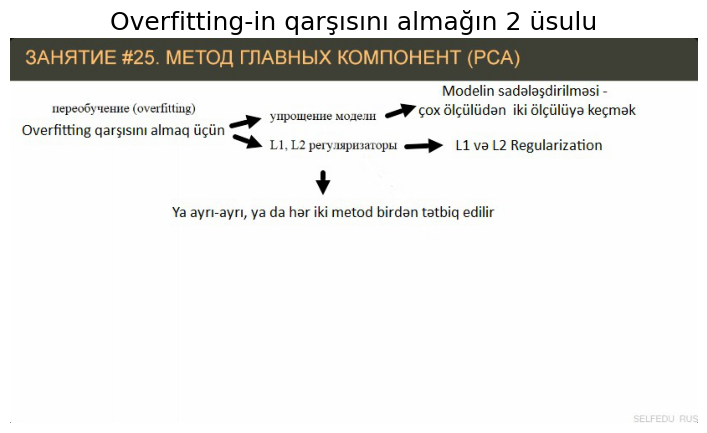

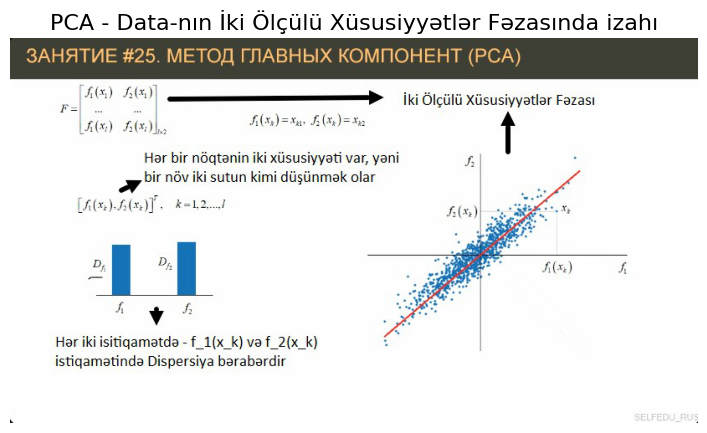

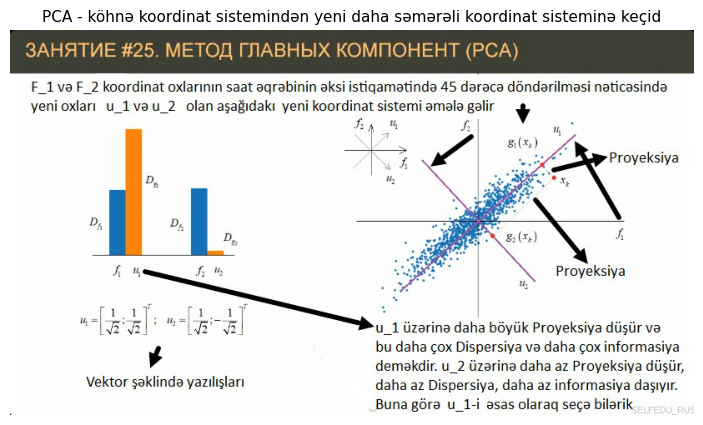

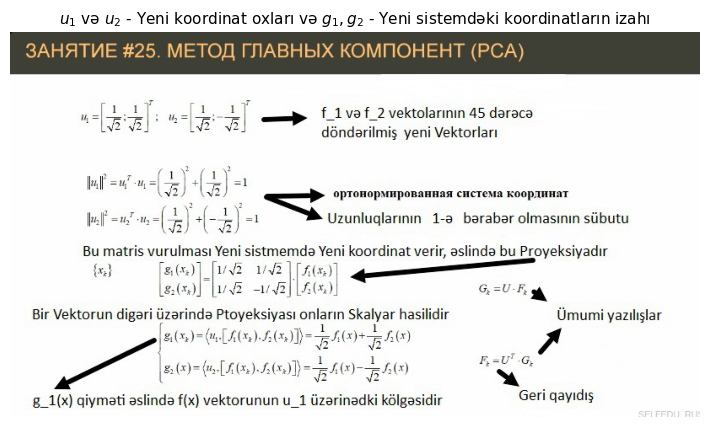

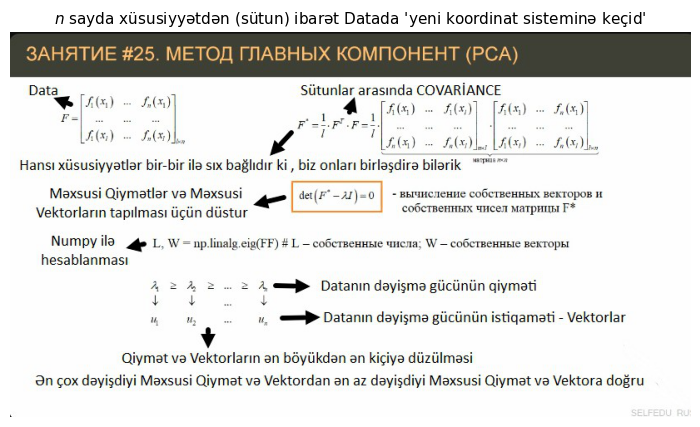

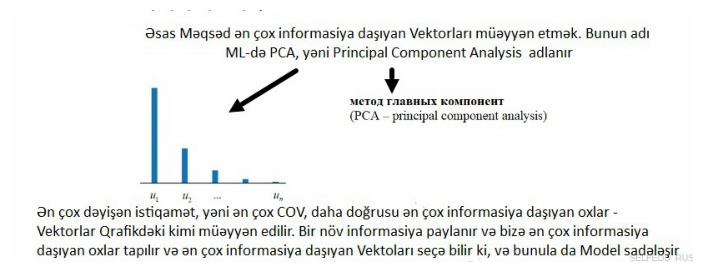

In [6]:
from PIL import Image

# Fayl yolunun əsas hissəsi
base_path = r'C:\Users\dell\Desktop\Selfedu\Pictures\ML_25_'

# Şəkilləri saxlayacağımız siyahı
image_list = []

# 1-dən 5-ə qədər olan şəkilləri dövr ilə açırıq
for i in range(1, 7):  # 1-dən 5-ə qədər
    full_path = f'{base_path}{i}.jpg'  # Fayl yolunu dinamik olaraq yaradırıq
    img = Image.open(full_path)
    image_list.append(img)  # Şəkili siyahıya əlavə edirik

# Nəticə: images siyahısında bütün yüklənmiş şəkillər olacaq

import matplotlib.pyplot as plt

# Şəkilləri göstərin
for i, image in enumerate(image_list):
    if i == 5:
        plt.figure(figsize=(8.8, 4))          
    else:     
        plt.figure(figsize=(25, 5))  # Şəkilin ölçüsü    
        
    if i < 1:
        plt.title("""Overfitting-in qarşısını almağın 2 üsulu""", size='18')
    elif i < 2:
        plt.title("""PCA - Data-nın İki Ölçülü Xüsusiyyətlər Fəzasında izahı""", size='16')
    elif i < 3:
        plt.title("""PCA - köhnə koordinat sistemindən yeni daha səmərəli koordinat sisteminə keçid""", size='11')         
    elif i < 4:
        plt.title("""$u_1$ və $u_2$ - Yeni koordinat oxları və $g_1, g_2$ - Yeni sistemdəki koordinatların izahı""", size='11')
    elif i < 5:
        plt.title("""$n$ sayda xüsusiyyətdən (sütun) ibarət Datada 'yeni koordinat sisteminə keçid'""", size='11') 
    elif i < 6:
        plt.title("""""", size='11')         
        
    plt.imshow(image)
    plt.axis('off')  # Oxları gizlətmək üçün
    plt.show()

### **PCA - Data-nın İki Ölçülü Xüsusiyyətlər Fəzasında izahı**

> **Şəkil Maşın Öyrənməsində ölçülərin azaldılması (dimensionality reduction) üçün ən çox istifadə olunan alqoritmlərdən biri olan PCA (Principal Component Analysis - Baş Komponentlər Analizi) mövzusuna aiddir.**

- **Gəlin şəkli hissə-hissə, sadə dildə izah edək:**

<br>

#### **1. PCA-nın Əsas Məqsədi**
> **PCA-nın ana məqsədi datadakı informasiyanı (variasiyanı) maksimum dərəcədə qoruyub saxlamaqla xüsusiyyətlərin (f-lərin) sayını azaltmaqdır. Məsələn, şəkildə iki xüsusiyyət ($f_1$ və $f_2$) var, biz onları daha az sayda xüsusiyyətlə ifadə etmək istəyirik.**

<br>

#### **2. Şəkildəki Riyazi İfadələr**
* **Matris ($F$):** **Sol yuxarıda gördüyünüz matris bizim giriş datamızdır. Hər bir sətir bir obyekti, sütunlar isə xüsusiyyətləri göstərir.**
* **$f_1(x_k)$ və $f_2(x_k)$:** **Bunlar hər hansı bir $x_k$ obyektinin koordinatlarıdır.**
* **$D_{f1}$ və $D_{f2}$ (Dispersiya):** **Sol tərəfdəki sütun qrafikləri xüsusiyyətlərin **dispersiyasını** (məlumatın nə dərəcədə yayıldığını) göstərir. PCA-da yüksək dispersiya = daha çox informasiya deməkdir.**

<br>

#### **3. Qrafikin İzahı (Əsas Məqam)**
- **Sağ tərəfdəki qrafikdə göy nöqtələr datanı, qırmızı xətt isə PCA-nın tapdığı birinci baş komponenti (PC1) göstərir:**
    * **İnformasiya itkisinin qarşısını almaq:** **Nöqtələr qırmızı xətt boyunca daha çox yayılıb. Bu o deməkdir ki, datadakı əsas variasiya məhz bu istiqamətdədir.**
    * **Proyeksiya:** **PCA hər bir göy nöqtəni o qırmızı xəttin üzərinə proyeksiya edir. Beləliklə, biz iki ox ($f_1, f_2$) yerinə, datanı tək bir yeni ox (qırmızı xətt) üzərində ifadə edə bilirik.**
    * **Korrelyasiya:** **Diqqət etsəniz, $f_1$ artdıqca $f_2$ də artır (güclü xətti əlaqə). PCA bu asılılığı istifadə edərək artıq xüsusiyyətləri silir və onları yeni bir oxda birləşdirir.**

<br>

#### **4. Nəticə etibarilə nə baş verir?**
- **1.  Ölçü azalır: Biz 2D qrafikdən 1D qrafikə (yalnız qırmızı xəttin üzərindəki mövqeyə) keçid edirik.**
- **2.  Yaddaşa qənaət: Data daha kiçik ölçüdə saxlanılır.**
- **3.  Vizualizasiya: Çoxölçülü datanı (məsələn, 100 xüsusiyyəti) 2 və ya 3 ölçüyə salıb qrafikdə görmək mümkün olur.**

**Xülasə:** 
> **Şəkildə PCA-nın datadakı ən yüksək variasiya istiqamətini (qırmızı xətti) necə tapdığı və məlumatın həmin xətt üzərində necə cəmləşdiyi göstərilmişdir.**

### **$D_{f1}$ və $D_{f2}$ niyə bərabərdir?**

> **Şəkildəki sol tərəfdəki sütun qrafiklərinə ($D_{f1}$ və $D_{f2}$) diqqət yetirsək, onların hündürlüklərinin demək olar ki, eyni olduğunu görürük. Bunun bir neçə fundamental səbəbi ola bilər:**

<br>

#### **1. Data Standartlaşdırılıb (Scaling)**
- **PCA alqoritmini tətbiq etməzdən əvvəl atılan ən vacib addım datanı standartlaşdırmaqdır (Standardization):** 
    * **Əgər biz hər iki xüsusiyyəti ($f_1$ və $f_2$) orta qiyməti 0, dispersiyası isə 1 olacaq şəkildə miqyaslandırsaq, onların dispersiyaları bərabərləşir ($D_{f1} = D_{f2} = 1$).** 
    * **Niyə edilir?** **Çünki əgər $f_1$ gəlir (minlərlə), $f_2$ isə yaş (onlarla) olsa, PCA böyük rəqəmlərə daha çox əhəmiyyət verəcək və nəticə səhv olacaq. Dispersiyaların bərabər olması modelin hər iki xüsusiyyətə eyni dərəcədə "ədalətli" yanaşdığını göstərir.**

<br>

#### **2. Xüsusiyyətlərin Paylanma Oxşarlığı**
- **Qrafikdəki göy nöqtələrə baxsaq, onların $f_1$ oxu boyunca yayıldığı məsafə ilə $f_2$ oxu boyunca yayıldığı məsafə vizual olaraq bir-birinə çox yaxındır.**
* **Nöqtələr 45 dərəcəlik bir xətt boyunca simmetrik paylanıb.** 
* **Bu o deməkdir ki, datanın "səpələnmə dərəcəsi" hər iki istiqamətdə eynidir.**

<br>

#### **3. PCA-nın tapdığı "Yeni" Oxun Gücü**
- **Şəkildəki qırmızı xətt (birinci baş komponent) məhz o dispersiyaların "cəmini" öz üzərinə götürmək üçün oradadır.**
- $f_1$ və $f_2$ **ayrılıqda eyni miqdarda informasiya (eyni dispersiya) daşısa da, onlar bir-biri ilə korrelyasiyadadırlar.**
- **PCA bu iki bərabər dispersiyanı birləşdirib, daha böyük bir dispersiyaya malik olan tək bir ox yaradır.**

<br>

#### **Xülasə**
> **Şəkildə dispersiyaların bərabər göstərilməsi çox gümman ki, StandardScaler (və ya bənzər bir metod) tətbiq edildikdən sonra datanın hər iki ölçüdə eyni çəkiyə malik olduğunu vurğulamaq üçündür. Əgər biri digərindən çox böyük olsaydı, PCA avtomatik olaraq həmin oxu "əsas" seçərdi və digər vacib məlumatları itirə bilərdik.**

#### **PCA alqoritminin – yəni datanın köhnə koordinat sistemindən yeni, daha səmərəli koordinat sisteminə keçidi**

> **Şəkil PCA (Baş Komponentlər Analizi) alqoritminin riyazi və həndəsi olaraq ən pik nöqtəsini – yəni datanın köhnə koordinat sistemindən yeni, daha səmərəli koordinat sisteminə keçidini izah edir.**

- **Gəlin hər bir detalı addım-addım təhlil edək:**

<br>

#### **1. Ümumi Prinsip: Niyə belə etdik?**
- **Bizim ilkin datamız $f_1$ və $f_2$ oxları üzərində paylanıb. Diqqət etsəniz, bu iki dəyişən arasında güclü korrelyasiya var (yəni $f_1$ artdıqca $f_2$ də artır). Bu o deməkdir ki, hər iki ox əslində eyni informasiyanın böyük bir hissəsini təkrarlayır.**
- **Məqsədimiz:** **Datanı elə yeni oxlara (baş komponentlərə) köçürməkdir ki:**
    - **1.  Birinci ox ($u_1$) datadakı maksimum dispersiyanı (informasiyanı) özündə cəmləsin.**
    - **2.  İkinci ox ($u_2$) isə birinciyə perpendikulyar olsun və qalan minimal məlumatı daşısın.**

<br>

- $\large{⚠️}$ **Diqqət**
> **BU $u_1$ və $u_2$ oxları $f_1$ və $f_2$ oxlarının xəyali olaraq saat ərəbinin əksi istqamətində 45 dərəcə döndərilməsi nəticəsində yaranır**

<br>

#### **2. $u_1$ və $u_2$ nədir? (Vektorlar)**
- **Şəkildə sol aşağıda gördüyünüz $u_1$ və $u_2$ Vahid Vektorlardır (Unit Vectors):**
    $$
    u_1 = \left[ \frac{1}{\sqrt{2}}, \frac{1}{\sqrt{2}} \right]^T, \quad u_2 = \left[ \frac{1}{\sqrt{2}}, -\frac{1}{\sqrt{2}} \right]^T
    $$
    
    - **$u_1$:** **Bu vektor 45 dərəcəlik bucaq altında yönəlib. Qrafikdə bənövşəyi rəngli əsas xətt məhz bu istiqamətdədir. Data ən çox bu istiqamətdə uzanır.**
    - **$u_2$:** **Bu vektor $u_1$-ə perpendikulyardır. O, datanın ən az yayıldığı (eni) istiqaməti göstərir.**
    - **Niyə bu rəqəmlər?** **Çünki $\sqrt{1/2}^2 + \sqrt{1/2}^2 = 1$ edir. Bu, vektorun uzunluğunun 1 olduğunu və sadəcə istiqamət bildirdiyini göstərir.**
      - **Çünki istiqamət (1,1) kimidir (yəni 45° istiqamət):**
      - **Amma (1,1)-in uzunluğu:**

      $$
      \sqrt{1^2 + 1^2} = \sqrt{2}
      $$

       - **Unit etmək üçün bölürük:**

      $$
      \frac{1}{\sqrt{2}} \cdot (1,1) = \left(\frac{1}{\sqrt{2}}, \frac{1}{\sqrt{2}}\right)
      $$


      - **(1,1) vektorunu 1 uzunluğa salmaq üçün $\sqrt{2}$-yə bölürük → ona görə $\left[\frac{1}{\sqrt{2}}, \frac{1}{\sqrt{2}}\right]$ çıxır.**     

<br>

#### **3. Dispersiyalar ($D$) niyə müxtəlif oldu?**
- **Sol tərəfdəki bar-qrafikə baxın:**
    * **Əvvəl:** $D_{f1}$ və $D_{f2}$ **demək olar ki, bərabər idi (göy sütunlar). Bu o deməkdir ki, köhnə oxların heç biri datanı təkbaşına tam ifadə edə bilmirdi.**
    * **Sonra ($D_{u1}$):** **Narıncı sütun çox hündürdür! Çünki biz oxu dəyişib datanın ən çox uzandığı istiqamətə ($u_1$) qoyduq. İndi bütün informasiya (dispersiya) bu oxda cəmləndi.**
    * **Sonra ($D_{u2}$):** **Çox kiçik bir narıncı sütun qaldı. Çünki o istiqamətdə demək olar ki, dəyişiklik (yayılma) yoxdur.**

<br>

#### **4. Qrafik neçə o hala gəldi? (Proyeksiya)**
- **Qrafikdəki $x_k$ nöqtəsinə və ondan oxlara çəkilən qırıq-qırıq xətlərə baxın:**
    * **$g_1(x_k)$:** **Bu, nöqtənin yeni $u_1$ oxu üzərindəki proyeksiyasıdır. Artıq obyektin "əsas kimliyi" bu rəqəmdir.**
    * **$g_2(x_k)$:** **Bu rəqəm isə nöqtənin $u_1$ xəttindən nə qədər kənara çıxdığını (səhvini və ya incə detalını) göstərir.**

**Proses belə oldu:**
- **1.  Datanın mərkəzi tapıldı (0,0 nöqtəsi).**
- **2.  Data buludunun içindən ən uzun məsafəni keçən düz xətt ($u_1$) çəkildi.**
- **3.  Bütün nöqtələr bu yeni xəttin üzərinə "yıxıldı" (proyeksiya edildi).**
- **4.  Köhnə $f_1, f_2$ koordinat sistemi ləğv edildi, yeni $u_1, u_2$ sistemi yaradıldı.**

<br>

#### **Yekun Nəticə:**
- **Biz bu hərəkətlə nə qazandıq?**
> **Əgər biz $u_2$ oxunu tamamilə silsək (çünki $D_{u2}$ çox kiçikdir), datanın bəlkə də 95%-ni qoruyub saxlayaraq onu iki ölçüdən bir ölçüyə (2D-dən 1D-yə) endirmiş oluruq. Bu, həm hesablama sürətini artırır, həm də datadakı "küyü" (noise) təmizləyir.**

### **$u_1$ və $u_2$ vektorlarının necə doğulduğunun Riyazi izahı**

> **Bu işin "mətbəxi" məhz bura – Xüsusi Vektorlar (Eigenvectors) və Xüsusi Qiymətlər (Eigenvalues) mövzusuna söykənir. Gəlin, o $u_1$ və $u_2$ vektorlarının necə doğulduğunu riyazi olaraq addım-addım izah edim.**

<br>

#### **1. Kovariasiya Matrisi ($\Sigma$)**
- **Hər şey datanın daxili əlaqələrini göstərən Kovariasiya Matrisinin hesablanması ilə başlayır. Əgər bizim datamız $f_1$ və $f_2$ oxlarından ibarətdirsə, matris belə görünür:**

    $$
    \Sigma = \begin{pmatrix} \text{Var}(f_1) & \text{Cov}(f_1, f_2) \\ \text{Cov}(f_2, f_1) & \text{Var}(f_2) \end{pmatrix}
    $$

    * **Var:** **Hər bir xüsusiyyətin öz daxilindəki yayılması.**
    * **Cov:** **İki xüsusiyyətin bir-biri ilə nə dərəcədə əlaqəli (korrelyasiyada) olduğu.**

<br>

#### **2. Xüsusi Qiymət Tənliyi (Characteristic Equation)**
- **Biz elə bir $\lambda$ (lambda) və $u$ vektoru tapmalıyıq ki, bu tənliyi ödəsin:**
    $$
    \Sigma u = \lambda u
    $$

    - **Bu tənlik bizə deyir ki: "Mən bu $u$ vektorunu kovariasiya matrisi ilə vurduqda, o öz istiqamətini dəyişməsin, sadəcə $\lambda$ qədər uzansın və ya qısalsın."**

- **Bunu tapmaq üçün determinantdan istifadə edirik:**
    $$\det(\Sigma - \lambda I) = 0$$

    - **Buradan tapılan $\lambda_1$ və $\lambda_2$ sizin şəkildə gördüyünüz o narıncı sütunların ($D_{u1}$ və $D_{u2}$) hündürlüyüdür. Yəni hər bir oxun nə qədər informasiya (dispersiya) daşıdığı rəqəmsal olaraq ortaya çıxır.**

<br>

#### **3. Xüsusi Vektorların ($u_1, u_2$) tapılması**
- **Tapdığımız hər bir $\lambda$ üçün tənliyi yenidən həll edib $u$ vektorlarını tapırıq.**

* **$\lambda_{max}$ (ən böyük qiymət):** **Bu qiymətə uyğun gələn $u_1$ vektoru Birinci Baş Komponentdir. O, datanın ən çox uzandığı (ən böyük dispersiyaya malik) istiqaməti göstərir.**
* **Digər $\lambda$:** **Ona uyğun gələn $u_2$ isə həmişə $u_1$-ə perpendikulyar olur və qalan dispersiyanı göstərir.**

<br>

#### **4. Şəkildəki $1/\sqrt{2}$ rəqəmi haradan gəldi?**
- **Sizin şəkildəki $u_1 = [1/\sqrt{2}, 1/\sqrt{2}]$ nümunəsi datanın tam 45 dərəcəlik bucaq altında paylandığı (yəni $f_1$ və $f_2$ arasındakı korrelyasiyanın tam olduğu) hala aiddir.** 
- **Vektorun uzunluğunu 1-ə bərabər etmək üçün (normalizasiya) biz hər bir komponenti vektorun normasına bölürük:**
    $$\|u\| = \sqrt{(1)^2 + (1)^2} = \sqrt{2}$$
    - **Ona görə də vahid vektor $1/\sqrt{2}$ olur.**

<br>

#### **Ümumi Məntiqin Xülasəsi**
- **1.  Kovariasiya Matrisi datanın daxili "xəritəsini" çıxarır.**
- **2.  Xüsusi Qiymətlər ($\lambda$) bu xəritədə hansı istiqamətin daha "zəngin" (çox məlumatlı) olduğunu deyir.**
- **3.  Xüsusi Vektorlar ($u$) isə həmin istiqamətlərin koordinatlarını (oxlarını) bizə verir.**

> **Bu proses bitdikdən sonra biz köhnə $f_1$ və $f_2$ oxlarını "zibil qutusuna" atırıq və datanı yeni, daha güclü $u_1$ oxu üzərində ifadə edirik.**

### **$g_1, g_2$: Yeni (döndərilmiş) sistemdəki koordinatlardırın izahı**
### **$u_1$ və $u_2$ yeni koordinat oxlarının izahı**
- #### **Verilmiş məlumatı (vektoru) yeni, daha əlverişli bir koordinat sisteminə köçürmək**

> **Şəkildə əks olunan düsturlar xətti cəbrin ən vacib mövzularından biri olan koordinat sisteminin dəyişdirilməsi və ortonormal bazisə proyeksiyanı izah edir. Burada əsas məqsəd verilmiş məlumatı (vektoru) yeni, daha əlverişli bir koordinat sisteminə köçürməkdir.**

- **Gəlin bu düsturları məntiqi ardıcıllıqla, cüt-cüt izah edək:**

<br>

#### **1. Yeni Bazis Vektorlarının Təyini ($u_1$ və $u_2$)**
- **İlk sətirdə iki yeni vektor təyin olunur:**
    $$
    u_1 = \left[ \frac{1}{\sqrt{2}}; \frac{1}{\sqrt{2}} \right]^T; \quad u_2 = \left[ \frac{1}{\sqrt{2}}; -\frac{1}{\sqrt{2}} \right]^T
    $$

    - **Bu vektorlar bizim yeni koordinat oxlarımızdır. Diqqət etsəniz, bu vektorlar standart oxlara nisbətən 45° döndərilib. Onlar yeni sistemin "vahid ölçüləri" rolunu oynayır.**

<br>

#### **2. Ortonormallıq Şərti (Vektorların Uzunluğu)**
- **İkinci blokda həmin vektorların norması (uzunluğu) yoxlanılır:**
    $$\|u_1\|^2 = u_1^T \cdot u_1 = \left(\frac{1}{\sqrt{2}}\right)^2 + \left(\frac{1}{\sqrt{2}}\right)^2 = 1$$
    $$\|u_2\|^2 = u_2^T \cdot u_2 = \left(\frac{1}{\sqrt{2}}\right)^2 + \left(-\frac{1}{\sqrt{2}}\right)^2 = 1$$

    - **Məna:** **Bu hesablamalar sübut edir ki, hər iki vektorun uzunluğu 1-ə bərabərdir. Eyni zamanda, $u_1$ və $u_2$ arasındakı skalyar hasil sıfırdır (onlar bir-birinə perpendikulyardır). Şəkildəki "ортонормированная система координат" sözü də elə bunu ifadə edir: həm perpendikulyar, həm də vahid uzunluğa malik oxlar sistemi.**

<br>

#### **3. Matris Formasında Koordinat Çevrilməsi**
- **Orta hissədəki düstur köhnə koordinatlardan yeni koordinatlara keçidi göstərir:**
    $$\begin{bmatrix} g_1(x_k) \\ g_2(x_k) \end{bmatrix} = \begin{bmatrix} 1/\sqrt{2} & 1/\sqrt{2} \\ 1/\sqrt{2} & -1/\sqrt{2} \end{bmatrix} \cdot \begin{bmatrix} f_1(x_k) \\ f_2(x_k) \end{bmatrix}$$

    * $f_1, f_2$: **Orijinal (köhnə) koordinat sistemindəki nöqtələrdir.**
    * $g_1, g_2$: **Yeni (döndərilmiş) sistemdəki koordinatlardır.**
    * **Məna:** **Bu matris vurulması məlumatın oxlarını elə dəyişir ki, biz dataya fərqli bucaqdan baxırıq. Bu, adətən PCA (Əsas Komponentlər Analizi) kimi alqoritmlərdə datanı ən çox yayıldığı istiqamət üzrə düzmək üçün istifadə olunur.**

<br>

#### **4. Proyeksiya və Skalyar Hasil (Ən vacib hissə)**
- **Şəklin aşağısındakı sistem tənlikləri bu keçidin daxili məntiqini (skalyar hasili) izah edir:**
    $$\begin{cases} g_1(x) = \langle u_1, [f_1(x), f_2(x)] \rangle = \frac{1}{\sqrt{2}}f_1(x) + \frac{1}{\sqrt{2}}f_2(x) \\ g_2(x) = \langle u_2, [f_1(x), f_2(x)] \rangle = \frac{1}{\sqrt{2}}f_1(x) - \frac{1}{\sqrt{2}}f_2(x) \end{cases}$$

    - **Bunun mənası nədir?**
    > **Bir nöqtənin yeni ox üzərindəki koordinatını tapmaq üçün, həmin nöqtəni (vektoru) yeni oxun vahid vektoru ($u_1$ və ya $u_2$) üzərinə proyeksiya etməliyik.**
    * **Riyazi olaraq, bir vektorun digəri üzərinə proyeksiyası onların skalyar hasilidir ($\langle \cdot , \cdot \rangle$).**
    * **Yəni, $g_1(x)$ qiyməti əslində $f$ vektorunun $u_1$ oxu üzərindəki "kölgəsi"nin uzunluğudur.**

<br>

#### **5. Keçid Düsturları ($G_k = U \cdot F_k$ və $F_k = U^T \cdot G_k$)**
- **Sağ tərəfdə çərçivəyə alınmış düsturlar ümumi qanunauyğunluğu göstərir:**
    - **1.  $G_k = U \cdot F_k$: Köhnə dünyadan ($F$) yeni dünyaya ($G$) keçid. $U$ burada keçid matrisidir.**
    - **2.  $F_k = U^T \cdot G_k$: Yeni dünyadan köhnəyə geri qayıdış.** 
    - **Maraqlı fakt: Ortonormal matrislərdə tərs matris ($U^{-1}$) onun transponirə olunmuşuna ($U^T$) bərabərdir. Buna görə də geri qayıtmaq üçün sadəcə matrisin sətir və sütunlarının yerini dəyişib vurmaq kifayətdir.**

<br>

- **Xülasə:** 
> **Şəkildəki proses datanın oxlarını döndərmək, hər bir nöqtənin yeni oxlar üzərindəki proyeksiyasını (skalyar hasil vasitəsilə) tapmaq və bu keçidin matris formasını ifadə etməkdir. Bu, Maşın Öyrənməsində (məsələn, SVM-də və ya Ölçülülüyün Azaldılmasında) məkanda oriyentasiyanı dəyişmək üçün təməl addımdır.**

#### **$n$ sayda xüsusiyyətdən (sütun) ibarət Datada "yeni koordinat sisteminə keçid" prosesinin arxa fonunda baş verən riyazi hesablamalar**

>  **şəkildəki düsturlar, əslində əvvəlki söhbətimizdə toxunduğumuz "yeni koordinat sisteminə keçid" prosesinin arxa fonunda baş verən riyazi hesablamaları (PCA - Əsas Komponentlər Analizi məntiqini) izah edir.** 

<br>

#### **1. Data Matrisi ($F$) və Kovariasiya Matrisinə yaxın model ($F^*$)**
- **İlk olaraq datanın özünü və ondan alınan nəticəni görürük:**
$$F = \begin{bmatrix} f_1(x_1) & \dots & f_n(x_1) \\ \dots & \dots & \dots \\ f_1(x_l) & \dots & f_n(x_l) \end{bmatrix}_{l \times n}; \quad F^* = \frac{1}{l} \cdot F^T \cdot F = \frac{1}{l} \cdot \underbrace{ \begin{bmatrix} f_1(x_1) & \dots & f_1(x_l) \\ \dots & \dots & \dots \\ f_n(x_1) & \dots & f_n(x_l) \end{bmatrix}_{n \times l} \cdot \begin{bmatrix} f_1(x_1) & \dots & f_n(x_1) \\ \dots & \dots & \dots \\ f_1(x_l) & \dots & f_n(x_l) \end{bmatrix}_{l \times n} }_{\text{matris } n \times n}$$

* **$F$ matrisi:** **Sizin əlinizdə olan xam datadır. Sətirlər ($l$) müşahidələri (məsələn, müştərilər), sütunlar ($n$) isə xüsusiyyətləri (məsələn, gəlir, yaş) göstərir. $l$ sayda müşahidə (sətir) və $n$ sayda xüsusiyyətdən (sütun) ibarətdir.**
* **$F^T$:** $F$ **matrisinin transponiri (sətir və sütunların yerinin dəyişməsi).**
* **$F^*$ matrisi:** **Bu, xüsusiyyətlər arasındakı əlaqəni göstərən matrisdir.**
* **$F^T \cdot F$ əməliyyatı:** **Sütunların bir-biri ilə necə dəyişdiyini (kovariasiyasını) tapır.**
* **$\frac{1}{l}$:** **Nəticəni müşahidələrin sayına bölərək ortalama dəyəri (normallaşmanı) tapmaq üçün istifadə edilən skalyar vuruqdur.**
* **Məna:** $F^*$ **bizə deyir ki, hansı xüsusiyyətlər bir-biri ilə sıx bağlıdır. Əgər iki sütun eyni şeyi deyirsə, biz onları birləşdirə bilərik.**

<br>

#### **2. Xarakteristik Tənlik:**
$$
\det(F^* - \lambda I) = 0
$$

- **Bu düstur "Məxsusi qiymətlərin" (Eigenvalues)** **tapılması üçün istifadə olunan tənlikdir.**
    -  **$\lambda$ (Lambda):** **Məxsusi qiymətdir (Eigenvalue).**
    - **$I$:** **Vahid matrisdir (diaqonalı 1, digər yerləri 0 olan matris).**
    - **$\det$ (Determinant):** **Matrisin sahə və ya həcm dəyişmə xüsusiyyətini göstərən tək bir rəqəmdir.**

- **Bunun mənası nədir?**
    - **Təsəvvür edin ki, əlinizdə bir rezin top var və onu sıxıb dartırsınız. Bəzi istiqamətlərdə top daha çox dartılır, bəzi istiqamətlərdə isə yerində qalır:**
        * **Məxsusi qiymət ($\lambda$):** **Həmin istiqamətdə dartılmanın gücünü (miqdarını) göstərir.**
        * **Məxsusi vektor ($u$):** **Dartılmanın hansı istiqamətdə baş verdiyini göstərir.**

- **Necə hesablanır?**
    - $F^*$ **matrisinin diaqonalından $\lambda$ çıxılır və alınan matrisin determinantı tapılaraq sıfıra bərabər edilir. Bu, riyazi olaraq bir tənlik (polinom) yaradır və biz həmin tənliyi həll edərək $\lambda_1, \lambda_2 \dots$ qiymətlərini tapırıq.**


<br>

#### **3. Python-da Kodu: `np.linalg.eig`**
- **Riyaziyyatı başa düşdükdən sonra Python bunu bizim yerimizə edir:**
    - `L, W = np.linalg.eig(FF)`

    * **$L$ (Eigenvalues):** **Tapılan $\lambda$ qiymətlərinin siyahısı.**
    * **$W$ (Eigenvectors):** **Həmin $\lambda$-lara uyğun gələn $u$ istiqamət vektorları.**

<br>

#### **4. Sıralamanın mənası: $\lambda_1 \ge \lambda_2 \ge \dots \ge \lambda_n$**
- **Bu, vacib məqamdır. Biz məxsusi qiymətləri böyükdən kiçiyə düzürük.**
    * **$\lambda_1$ (ən böyük):** **Datanın ən çox dəyişdiyi, ən çox informasiya daşıyan istiqamətdir.**
    * **$\lambda_n$ (ən kiçik):** **Datanın ən az dəyişdiyi istiqamətdir (çox vaxt bu "küy" və ya lazımsız məlumatdır).**

<br>

#### **5. Bizə nə xeyri var? (Niyə bunları edirik?)**
- **Bu hesablamalar PCA (Principal Component Analysis) alqoritminin "ürəyidir". Xeyirləri bunlardır:**

- **1.  Ölçülülüyün azaldılması: Məsələn, əlinizdə 100 dənə parametr (sütun) var. Amma hesablayıb görürsünüz ki, ilk 2 dənə $\lambda$ (məxsusi qiymət) ümumi informasiyanın 95%-ni izah edir. O zaman digər 98 sütunu atıb, işinizi cəmi 2 sütunla (yeni koordinatlarla) davam etdirirsiniz.**
- **2.  Sürət: Daha az sütun = daha sürətli model.**
- **3.  Vizuallaşdırma: 10 parametrli datanı görmək qeyri-mümkündür, amma onu 2 məxsusi vektora proyeksiyalayıb ($u_1, u_2$ oxlarında) qrafikini çəkə bilərsiniz.**
- **4.  Küyün təmizlənməsi: Kiçik $\lambda$-lara uyğun gələn istiqamətləri silməklə, datadakı təsadüfi səhvləri və küyü təmizləmiş olursunuz.**

<br>

- **Xülasə:**
> $F^*$ **ilə datanın daxili strukturunu ölçürük, $\det(F^* - \lambda I)=0$ ilə bu strukturun "gücünü" tapırıq, sıralayırıq və ən güclü istiqamətləri ($u_1, u_2 \dots$) seçərək köhnə qarışıq datanı yeni, təmiz koordinat sisteminə köçürürük.**

### **Məxsusi Vektor bəs harad idi**

> D**üsturda biz $\lambda$ (ədəd) tapsaq da, məxsusi vektor ($u$) sanki "gizli" qalır. Gəlin bunu addım-addım, həm riyazi, həm də vizual olaraq izah edək.**

<br>

#### **1. Məxsusi Vektor Harada "Gizlənib"?**
- **Riyaziyyatda əsas tənlik belədir:**
    $$F^* \cdot u = \lambda \cdot u$$

    - **Bu tənlik bizə deyir ki: "Elə bir $u$ vektoru var ki, mən onu $F^*$ matrisinə vurduqda, o vektorun istiqaməti dəyişmir, sadəcə boyu $\lambda$ qədər uzanır və ya qısalır."**

> **Bu $\det(F^* - \lambda I) = 0$ tənliyi isə yuxarıdakı tənliyin həll olunması üçün bir "ayaq yoludur". Biz əvvəlcə $\lambda$-nı tapırıq ki, sonra həmin $\lambda$-nı yerinə qoyub $u$-nu tapa bilək.**

<br>

#### **2. Məxsusi Vektor ($u$) Necə Əmələ Gəlir? (Hesablanma qaydası)**
- $\lambda$-nı **tapdıqdan sonra onu yenidən əsas tənliyə qoyuruq:**
    $$(F^* - \lambda I) \cdot u = 0$$

    - **Burada $u = [x, y]$ kimi bir vektordur. Biz bu xətti tənliklər sistemini həll edirik və nəticədə aldığımız $[x, y]$ qiymətləri bizim Məxsusi Vektorumuzdur.**

- **Sadə bir misal:**
    - **Təsəvvür edin ki, $\lambda = 2$ tapmısınız. Bu o deməkdir ki, tapacağınız $u$ istiqamətində data 2 dəfə güclüdür (və ya 2 dəfə çox yayılıb).**

<br>

#### **3. "İstiqamət" Deyəndə Nəyi Nəzərdə Tuturuq?**
- **Bunu ən yaxşı datanın paylanması (scatter plot) üzərində anlamaq olar:**

    * **Data Buludu:** **Təsəvvür edin ki, koordinat sistemində bir çox nöqtələriniz var və onlar ellips formasında yayılıb.**
    * **Birinci Məxsusi Vektor ($u_1$):** **Bu vektor həmin ellipsin **ən uzun oxu** boyunca uzanır. Yəni datanın ən çox səpələndiyi istiqaməti göstərir.**
    * **İkinci Məxsusi Vektor ($u_2$):** **Bu isə birinciyə perpendikulyar olan və datanın ikinci dərəcəli əhəmiyyətli yayılma istiqamətini göstərən vektordur.**

<br>

#### **4. Bəs "Dartılma" Haradan Çıxdı?**
- **"Dartılma" ifadəsi matrisin funksiyasını izah etmək üçündür:**
- **1.  Sizin xam datanız ($F$) əvvəlcə dağınıq ola bilər.**
- **2.  $F^*$ matrisi bu datanın daxili əlaqəsini (strukturunu) təmsil edir.**
- **3.  $\lambda$ tapılanda biz bilirik ki, bu strukturun "ana xətləri" hansı gücdədir.**
- **4.  $u$ isə bizə həmin ana xətlərin hansı bucaq altında yerləşdiyini deyir.**

<br>

- **Nəticə olaraq:**
> **Məxsusi vektor ($u$) göydən düşmür; o,** $F^*$ **matrisinin daxilindəki gizli asılılıqların coğrafi xəritəsidir**. $\det(F^* - \lambda I) = 0$ **isə bu xəritəni oxumaq üçün istifadə etdiyimiz "kod açarıdır".**